#  Earthquake–Tsunami Feature Binning and t-/d-Weights
## Group 2: Kareem Piper, Cheyanne Allred-Lopez, Jean Pendergraft, Jillian Mouser

This notebook:

- Loads the **Global Earthquake–Tsunami Risk Assessment** dataset.
- Bins key continuous features using seismology-informed thresholds.
- Plots distributions for selected variables.
- Computes **t-weights** and **d-weights** for binned features with respect to the tsunami class (`tsunami = 0` → No, `1` → Yes).
- Exports separate CSV tables for each feature's t-/d-weights.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", context="talk")
plt.rcParams['figure.figsize'] = (10, 5)

# Load dataset
file_path = "/content/earthquake_data_tsunami.csv"
df = pd.read_csv(file_path)
print(f"Dataset loaded: {df.shape}")
df.head()

Dataset loaded: (782, 13)


,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
0,7.0,8,7,768,117,0.509,17.0,14.000,-9.7963,159.596,2022,11,1
1,6.9,4,4,735,99,2.229,34.0,25.000,-4.9559,100.738,2022,11,0
2,7.0,3,3,755,147,3.125,18.0,579.000,-20.0508,-178.346,2022,11,1
3,7.3,5,5,833,149,1.865,21.0,37.000,-19.2918,-172.129,2022,11,1
4,6.6,0,2,670,131,4.998,27.0,624.464,-25.5948,178.278,2022,11,1


In [ ]:
def compute_t_d_weights(df, feature_col, class_col='tsunami', class_labels=(0,1)):
    """Compute t-weights and d-weights for a binned feature vs tsunami class.

    t-weight: P(class | category) = count(category, class) / total count(category)
    d-weight: P(category | class) = count(category, class) / total count(class)
    All percentages * 100.
    """
    # Crosstab of category x class
    ct = pd.crosstab(df[feature_col], df[class_col])
    # Ensure columns for both classes exist
    for c in class_labels:
        if c not in ct.columns:
            ct[c] = 0
    ct = ct[list(class_labels)] # Changed from ct[class_labels] to ct[list(class_labels)]

    # Totals
    cat_totals = ct.sum(axis=1)          # per category
    class_totals = ct.sum(axis=0)       # per class
    grand_total = class_totals.sum()

    # Initialize result frame
    out = pd.DataFrame(index=ct.index)

    # For each class, compute counts, t, d
    for c in class_labels:
        count_col = f"Count_{c}"
        t_col = f"t_weight_{c}"
        d_col = f"d_weight_{c}"

        counts = ct[c]
        t_weight = (counts / cat_totals.replace(0, np.nan)) * 100
        d_weight = (counts / class_totals[c]) * 100

        out[count_col] = counts
        out[t_col] = t_weight.round(2)
        out[d_col] = d_weight.round(2)

    # Add total column per category
    out["TOTAL"] = cat_totals

    # Add a summary row
    summary = {}
    for c in class_labels:
        counts = class_totals[c]
        summary[f"Count_{c}"] = counts
        summary[f"t_weight_{c}"] = round((counts / grand_total) * 100, 2)
        summary[f"d_weight_{c}"] = 100.0
    summary["TOTAL"] = grand_total

    out.loc["Total"] = summary
    return out

##  Significance Score (`sig`) – Binning and Distribution

We bin the **Significance Score (`sig`)** using quartiles to create four ordered categories:

- **Low:** bottom 25% of all `sig` values  
- **Moderate:** 25th–50th percentile  
- **High:** 50th–75th percentile  
- **Very High:** top 25%  

This follows standard feature engineering practices for skewed, non-normally distributed continuous variables and preserves interpretability by mapping composite scores into ordered risk levels (Brykov et al., 2020).

> Brykov, M. N., Petryshynets, I., Pruncu, C. I., Efremenko, V. G., Pimenov, D. Y., Giasin, K., Sylenko, S. A., & Wojciechowski, S. (2020). Machine learning modelling and feature engineering in seismology experiment. *Sensors, 20*(15), 4228. https://doi.org/10.3390/s20154228


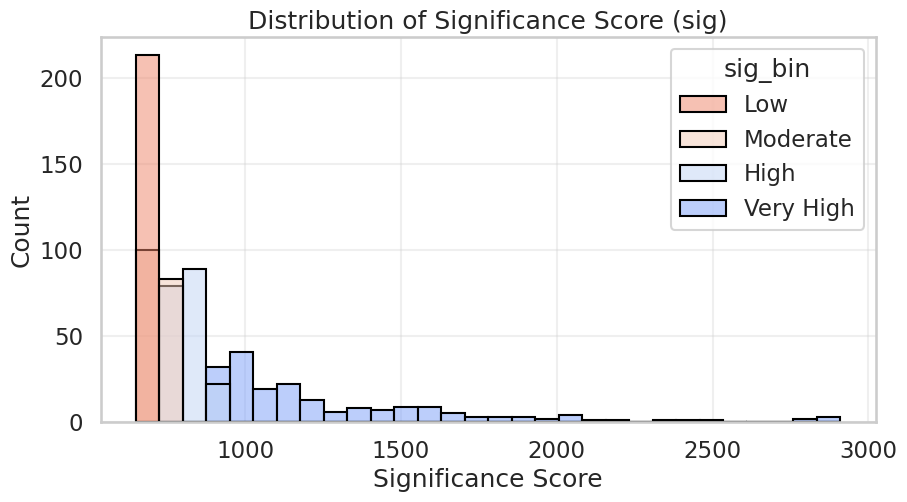

In [ ]:
# Binning sig via quartiles
sig_bins = np.quantile(df['sig'], [0, 0.25, 0.5, 0.75, 1])
sig_labels = ['Low', 'Moderate', 'High', 'Very High']
df['sig_bin'] = pd.cut(df['sig'], bins=sig_bins, labels=sig_labels, include_lowest=True)

sns.histplot(df, x='sig', hue='sig_bin', palette='coolwarm_r', edgecolor='black', bins=30)
plt.title('Distribution of Significance Score (sig)')
plt.xlabel('Significance Score')
plt.ylabel('Count')
plt.grid(alpha=0.3)
plt.show()

##  Number of Stations (`nst`) – Binning and Distribution

- **Very Low:** 0–50 stations  
- **Low:** 51–200 stations  
- **Moderate:** 201–500 stations  
- **High:** > 500 stations  

This reflects research on seismic network optimization, where sparse networks (≤ 50 stations) are linked to larger location errors and dense networks (> 500 stations) provide higher precision and better event detection (Espinosa-Ortega & Taisne, 2024; Kokowski & Rudziński, 2023).

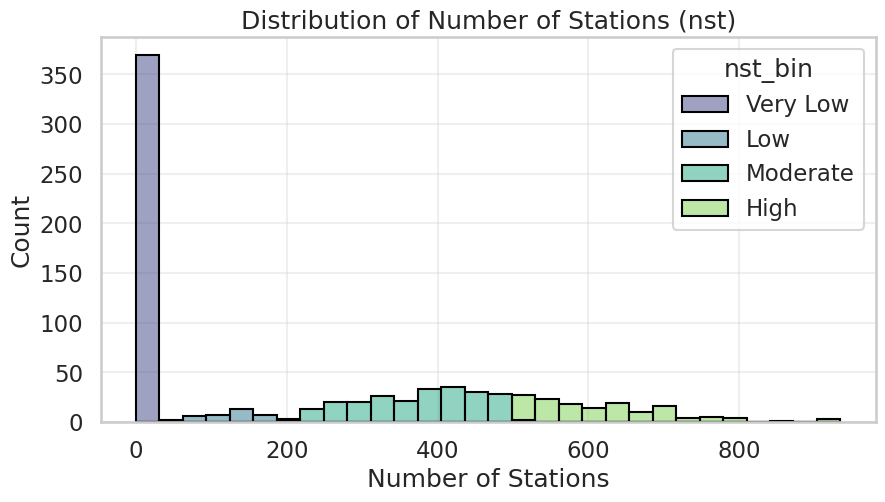

In [ ]:
# Binning nst
nst_bins = [0, 50, 200, 500, df['nst'].max() + 1]
nst_labels = ['Very Low', 'Low', 'Moderate', 'High']
df['nst_bin'] = pd.cut(df['nst'], bins=nst_bins, labels=nst_labels, right=False)

sns.histplot(df, x='nst', hue='nst_bin', palette='viridis', edgecolor='black', bins=30)
plt.title('Distribution of Number of Stations (nst)')
plt.xlabel('Number of Stations')
plt.ylabel('Count')
plt.grid(alpha=0.3)
plt.show()

##  Distance to Nearest Station (`dmin`) – Binning and Distribution

- **Excellent:** 0–1° (~0–111 km)  
- **Good:** 1–5° (~111–555 km)  
- **Fair:** 5–10° (~555–1,110 km)  
- **Poor:** > 10° (> 1,110 km)  

Smaller `dmin` values indicate events recorded close to a seismic network, which is associated with lower location uncertainty. Larger `dmin` values correspond to remote events and increased epicentral and depth error (Laporte et al., 2024; Wald et al., 2005).

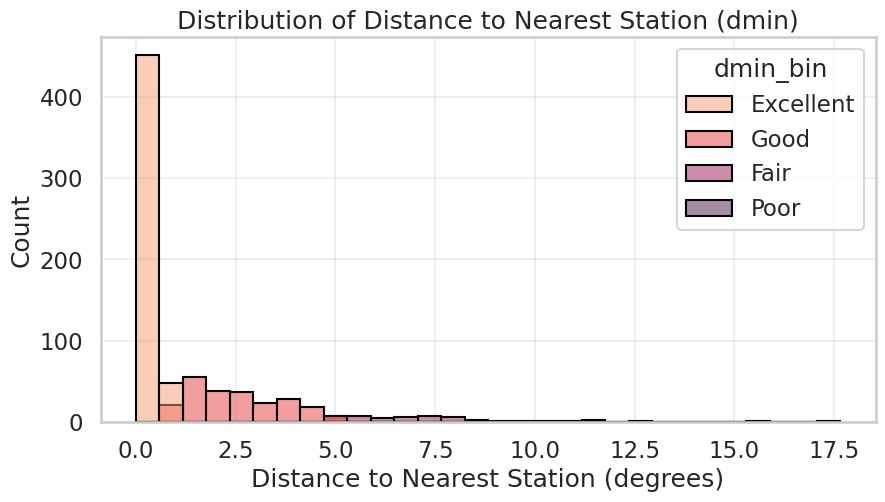

In [ ]:
# Binning dmin
dmin_bins = [0, 1, 5, 10, df['dmin'].max() + 1]
dmin_labels = ['Excellent', 'Good', 'Fair', 'Poor']
df['dmin_bin'] = pd.cut(df['dmin'], bins=dmin_bins, labels=dmin_labels, right=False)

sns.histplot(df, x='dmin', hue='dmin_bin', palette='rocket_r', edgecolor='black', bins=30)
plt.title('Distribution of Distance to Nearest Station (dmin)')
plt.xlabel('Distance to Nearest Station (degrees)')
plt.ylabel('Count')
plt.grid(alpha=0.3)
plt.show()

##  Depth Bins with t-Weights and d-Weights

We categorize **earthquake focal depth** into three standard seismological classes:

- **Shallow:** 0–70 km  
- **Mid-focus (Intermediate):** 70–300 km  
- **Deep-focus:** > 300 km  

Shallow events tend to cause more surface damage, while deeper events are less strongly felt at the surface but are important for understanding subduction zone processes (USGS; Wikipedia, 2025).

Here we treat **`tsunami` (0 = No, 1 = Yes)** as the class variable and depth category as the attribute. For each depth bin and tsunami class we compute:

- **t-weight**: \( \text{Count(category, class)} / \text{Total count(category across both classes)} \times 100 \) → how much of that category is contributed by a specific class.  
- **d-weight**: \( \text{Count(category, class)} / \text{Total count of that class across all categories} \times 100 \) → how much of that class is represented by that category.

The resulting table mirrors the structure used in Project II, with counts and weights for `tsunami = 0` and `tsunami = 1`. A CSV is exported for reporting.


In [ ]:
# Depth binning
depth_bins = [0, 70, 300, df['depth'].max() + 1]
depth_labels = ['Shallow', 'Mid', 'Deep']
df['depth_bin'] = pd.cut(df['depth'], bins=depth_bins, labels=depth_labels, right=False)

depth_weights = compute_t_d_weights(df, 'depth_bin', class_col='tsunami', class_labels=(0,1))
display(depth_weights)

# Save CSV
depth_path = "/content/depth_t_d_weights.csv"
depth_weights.to_csv(depth_path)
print(f" Depth t-/d-weights table saved to: {depth_path}")

try:
    from google.colab import files
    files.download(depth_path)
except Exception as e:
    print('Download helper (files.download) not available in this environment.')

,Count_0,t_weight_0,d_weight_0,Count_1,t_weight_1,d_weight_1,TOTAL
depth_bin,,,,,,,
Shallow,387,62.52,80.96,232,37.48,76.32,619
Mid,64,57.66,13.39,47,42.34,15.46,111
Deep,27,51.92,5.65,25,48.08,8.22,52
Total,478,61.13,100.00,304,38.87,100.00,782


 Depth t-/d-weights table saved to: /content/depth_t_d_weights.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##  Magnitude Bins with t-Weights and d-Weights

We group **earthquake magnitude** into three ordinal bins over the observed range (6.5–9.1):

- **Low:** 6.5–7.5  
- **Medium:** 7.6–8.5  
- **High:** 8.6–9.5  

Magnitude is measured on the moment magnitude scale, where each unit increase corresponds to roughly a 32-fold increase in energy release (Illinois Emergency Management Agency). This binning allows us to compare tsunami vs. non-tsunami events across escalating energy levels.

Using the same framework as above, we compute t-weights and d-weights for **magnitude bins vs. `tsunami` class** and export the resulting table.


In [ ]:
# Magnitude binning
mag_bins = [6.5, 7.5, 8.5, 9.5]
mag_labels = ['Low', 'Med', 'High']
df['magnitude_bin'] = pd.cut(df['magnitude'], bins=mag_bins, labels=mag_labels, include_lowest=True)

mag_weights = compute_t_d_weights(df, 'magnitude_bin', class_col='tsunami', class_labels=(0,1))
display(mag_weights)

mag_path = "/content/magnitude_t_d_weights.csv"
mag_weights.to_csv(mag_path)
print(f" Magnitude t-/d-weights table saved to: {mag_path}")

try:
    from google.colab import files
    files.download(mag_path)
except Exception as e:
    print('Download helper (files.download) not available in this environment.')

,Count_0,t_weight_0,d_weight_0,Count_1,t_weight_1,d_weight_1,TOTAL
magnitude_bin,,,,,,,
Low,421,60.84,88.08,271,39.16,89.14,692
Med,52,61.18,10.88,33,38.82,10.86,85
High,5,100.00,1.05,0,0.00,0.00,5
Total,478,61.13,100.00,304,38.87,100.00,782


 Magnitude t-/d-weights table saved to: /content/magnitude_t_d_weights.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##  Significance Score (`sig`) Bins with t-Weights and d-Weights

Having already binned `sig` into **Low / Moderate / High / Very High**, we now treat these bins as categorical attributes and evaluate how they relate to the tsunami outcome.

Again using `tsunami` as the class variable, we compute:

- **t-weight** for each (`sig_bin`, class) pair → proportion of that `sig` category contributed by a given class.  
- **d-weight** → proportion of that class’s events that fall in each `sig` category.

This aligns with the weighting examples from the assignment but remains grounded in the physically meaningful `sig` bins derived from quartiles (Brykov et al., 2020).


In [ ]:
sig_weights = compute_t_d_weights(df, 'sig_bin', class_col='tsunami', class_labels=(0,1))
display(sig_weights)

sig_path = "/content/sig_t_d_weights.csv"
sig_weights.to_csv(sig_path)
print(f" Significance (sig) t-/d-weights table saved to: {sig_path}")

try:
    from google.colab import files
    files.download(sig_path)
except Exception as e:
    print('Download helper (files.download) not available in this environment.')

,Count_0,t_weight_0,d_weight_0,Count_1,t_weight_1,d_weight_1,TOTAL
sig_bin,,,,,,,
Low,132,61.97,27.62,81,38.03,26.64,213
Moderate,114,62.30,23.85,69,37.70,22.70,183
High,106,55.79,22.18,84,44.21,27.63,190
Very High,126,64.29,26.36,70,35.71,23.03,196
Total,478,61.13,100.00,304,38.87,100.00,782


 Significance (sig) t-/d-weights table saved to: /content/sig_t_d_weights.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##  Yearly Quarters (`YearlyQs`) with t-Weights and d-Weights

To explore **seasonality**, we bin the event month into four **Yearly Quarters**:

- **Q1:** January–March (months 1–3)  
- **Q2:** April–June (4–6)  
- **Q3:** July–September (7–9)  
- **Q4:** October–December (10–12)  

This allows us to examine how tsunami vs. non-tsunami events distribute across quarters, which can reflect seasonal environmental conditions (e.g., storm seasons, regional monitoring effects). We again compute t-weights and d-weights for quarter vs. `tsunami` and export the results.


In [ ]:
def month_to_quarter(m):
    if 1 <= m <= 3:
        return "Q1"
    elif 4 <= m <= 6:
        return "Q2"
    elif 7 <= m <= 9:
        return "Q3"
    elif 10 <= m <= 12:
        return "Q4"
    else:
        return np.nan

df['YearlyQs'] = df['Month'].apply(month_to_quarter)

quarter_weights = compute_t_d_weights(df, 'YearlyQs', class_col='tsunami', class_labels=(0,1))
display(quarter_weights)

q_path = "/content/yearly_quarters_t_d_weights.csv"
quarter_weights.to_csv(q_path)
print(f" Yearly Quarters t-/d-weights table saved to: {q_path}")

try:
    from google.colab import files
    files.download(q_path)
except Exception as e:
    print('Download helper (files.download) not available in this environment.')

,Count_0,t_weight_0,d_weight_0,Count_1,t_weight_1,d_weight_1,TOTAL
YearlyQs,,,,,,,
Q1,122,62.24,25.52,74,37.76,24.34,196
Q2,101,57.06,21.13,76,42.94,25.00,177
Q3,126,61.76,26.36,78,38.24,25.66,204
Q4,129,62.93,26.99,76,37.07,25.00,205
Total,478,61.13,100.00,304,38.87,100.00,782


 Yearly Quarters t-/d-weights table saved to: /content/yearly_quarters_t_d_weights.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>